### author by yangshichen
### 注意：脚本仅供参考，使用前请仔细阅读

In [1]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn as sns
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy.sparse import csr_matrix
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
from scipy.sparse import issparse
import decoupler as dc
from sklearn.preprocessing import QuantileTransformer
from multiprocessing import Pool, cpu_count
from functools import partial
from sklearn.preprocessing import QuantileTransformer, StandardScaler
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=0)
scaler = StandardScaler()

import warnings
warnings.filterwarnings("ignore")

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, frameon=False)
sc._settings.ScanpyConfig.n_jobs=70

scanpy==1.9.8 anndata==0.9.2 umap==0.5.7 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 pynndescent==0.5.13


In [3]:
import os
os.environ["R_HOME"] = "/home/yangshichen//mambaforge/envs/QTL/lib/R"
os.environ["R_LIBS_USER"] = "/home/yangshichen/mambaforge/envs/QTL/lib/R/library"
import pandas as pd
import torch
import tensorqtl
from tensorqtl import  cis
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__} (CUDA {torch.version.cuda}), device: {device}")
print(f"pandas: {pd.__version__}")

torch: 2.4.1+cu121 (CUDA 12.1), device: cpu
pandas: 2.0.3


### PLINK质量控制

In [ ]:
# 转换VCF为PLINK格式 (已完成）
#plink --vcf WGS_variants.snp.AS.AVQSR.vcf.gz --make-bed --out /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/plink/cohort

In [4]:
cd /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/plink/

/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/plink


In [ ]:
# 1. 只保留 bi-allelic 变异 41044204/957
plink --bfile cohort \
      --biallelic-only strict \
      --make-bed \
      --out qc_step1_biallelic

In [ ]:
# 2. 过滤高缺失率变异（missing rate > 0.03） 32020569/957
plink --bfile qc_step1_biallelic \
      --geno 0.03 \
      --make-bed \
      --out qc_step2_geno_filtered

In [ ]:
# 3. 过滤低 MAF（小于 0.01）6862481/957
plink --bfile qc_step2_geno_filtered \
      --maf 0.01 \
      --make-bed \
      --out qc_step3_maf_filtered

In [ ]:
# 4. 过滤 Hardy-Weinberg 不平衡位点（HWE P < 1e-6） 6646684/957
plink --bfile qc_step3_maf_filtered \
      --hwe 1e-6 midp \
      --make-bed \
      --out qc_step4_hwe_filtered

In [ ]:
# 5. 评估异质性（heterozygosity）  6646684/941
# 5.1 计算每个个体的缺失率和杂合度
plink --bfile qc_step4_hwe_filtered \
      --missing \
      --het \
      --out qc_step5_het

In [6]:
# 5.2 用计算 heterozygosity 的均值和标准差
import pandas as pd
import os
os.chdir('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/plink/')

# 读取 PLINK 的 het 文件
het = pd.read_csv("qc_step5_het.het", delim_whitespace=True)

# 计算 F 值均值与标准差
mean_f = het["F"].mean()
std_f = het["F"].std()

# 设置过滤标准：±4 SD
lower = mean_f - 4 * std_f
upper = mean_f + 4 * std_f

# 标记保留或剔除的样本
het["keep"] = het["F"].between(lower, upper)

# 输出保留样本的 ID（FID 和 IID）
het.loc[het["keep"], ["FID", "IID"]].to_csv("qc_step5.het.keep.txt", sep="\t", index=False, header=False)

# 输出被剔除的样本（可选）
het.loc[~het["keep"], ["FID", "IID"]].to_csv("qc_step5.het.remove.txt", sep="\t", index=False, header=False)

In [ ]:
# 5.3 移除 outliers
plink --bfile qc_step4_hwe_filtered \
      --keep qc_step5.het.keep.txt \
      --make-bed \
      --out qc_step6_het_filtered

In [ ]:
# 6. 过滤亲缘关系过近个体（PI_HAT > 0.125）6646684/867
# 6.1 转换为 LDAK 格式或直接用 PLINK 进行 IBS 计算
plink --bfile qc_step6_het_filtered \
      --genome \
      --min 0.125 \
      --out qc_step7_relatedness

In [7]:
# 6.2 鉴定相关样本（保留一个）
import pandas as pd
import random

# 读入 .genome 文件
genome = pd.read_csv("qc_step7_relatedness.genome", delim_whitespace=True)

# 只保留 PI_HAT > 0.125 的亲缘对
related = genome[genome["PI_HAT"] > 0.125]

# 记录所有个体关系对
pairs = set()
for _, row in related.iterrows():
    pairs.add((row["FID1"], row["IID1"]))
    pairs.add((row["FID2"], row["IID2"]))

# 初始化一个集合，用于保留样本（优先保留较少重复出现的个体）
remove_set = set()
seen = set()

for _, row in related.iterrows():
    s1 = (row["FID1"], row["IID1"])
    s2 = (row["FID2"], row["IID2"])
    
    # 如果两人都还没被处理，随机保留一个，另一个放入 remove_set
    if s1 not in seen and s2 not in seen:
        keep = random.choice([s1, s2])
        remove = s1 if keep == s2 else s2
        remove_set.add(remove)
        seen.add(s1)
        seen.add(s2)

    # 如果其中一个已被处理，确保另一个也处理
    elif s1 in seen and s2 not in seen:
        remove_set.add(s2)
        seen.add(s2)
    elif s2 in seen and s1 not in seen:
        remove_set.add(s1)
        seen.add(s1)

# 转换为 DataFrame 并保存为 PLINK remove 文件格式
remove_df = pd.DataFrame(list(remove_set), columns=["FID", "IID"])
remove_df.to_csv("related_samples_to_remove.txt", sep="\t", index=False, header=False)

print(f"将移除 {len(remove_df)} 个样本，保留其对应的亲缘对中另一个个体。")

将移除 74 个样本，保留其对应的亲缘对中另一个个体。


In [ ]:
# 6.3 移除相关样本（保留一个）
plink --bfile qc_step6_het_filtered \
      --remove related_samples_to_remove.txt \
      --make-bed \
      --out qc_step7_unrelated

### Beagle 基因型填补（Imputation）+1KGP高覆盖参考

In [ ]:
# 使用 PLINK 把 .bed/.bim/.fam 转为 VCF
plink \
  --bfile qc_step7_unrelated \
  --recode vcf bgz \
  --out /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_variants.snp.plink

cd /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/
tabix -p vcf WGS_HP_variants.snp.plink.vcf.gz

In [ ]:
# 按染色体拆分 VCF 文件
cd /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/beagle/

for chr in {1..22}; do
  bcftools view -r $chr /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_variants.snp.plink.vcf.gz -Oz -o WGS.plink.chr${chr}.vcf.gz
  tabix -p vcf WGS.plink.chr${chr}.vcf.gz
done

In [ ]:
# 创建染色体编号重命名表
for i in {1..22}; do echo -e "${i}\tchr${i}"; done > rename_chr_to_chr_prefix.txt

# 1修改为chr1
for chr in {1..22}; do
  echo "Processing chr${chr}..."

  # 输入文件路径
  infile="WGS.plink.chr${chr}.vcf.gz"

  # 输出文件路径
  outfile="WGS.plink.chr${chr}.with_chr.vcf.gz"

  # 执行重命名染色体编号
  bcftools annotate --rename-chrs rename_chr_to_chr_prefix.txt -Oz -o "$outfile" "$infile"

  # 索引
  tabix -p vcf "$outfile"
done

In [ ]:
# map 1修改为chr1
#for chr in {1..22}; do
#  sed "s/^${chr} /chr${chr} /" /media/AnalysisDisk2/Yangshichen/2_My-Onek/plink.GRCh38.map/plink.chr${chr}.GRCh38.map \
#    > /media/AnalysisDisk2/Yangshichen/2_My-Onek/plink.GRCh38.map/plink.chr${chr}.with_chr.GRCh38.map
#done

In [ ]:
#只保留 SNP 和标准 INDEL（排除结构变异）
for chr in {1..22}; do
  bcftools view -v snps,indels -e 'REF="*"' -Oz -o WGS.plink.chr${chr}.cleaned.vcf.gz WGS.plink.chr${chr}.with_chr.vcf.gz
  tabix -p vcf WGS.plink.chr${chr}.cleaned.vcf.gz
done

In [ ]:
#使用 Beagle 进行基因型填补
for chr in {1..22}; do
   java -Xmx64g -jar /media/AnalysisDisk2/Yangshichen/2_My-Onek/beagle.29Oct24.c8e.jar \
    gt=WGS.plink.chr${chr}.cleaned.vcf.gz \
    ref=/media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP/1kGP_high_coverage_Illumina.chr${chr}.filtered.SNV_INDEL_SV_phased_panel.vcf.gz \
    map=/media/AnalysisDisk2/Yangshichen/2_My-Onek/plink.GRCh38.map/plink.chr${chr}.with_chr.GRCh38.map \
    out=/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/beagle_after/WGS.beagle.imputed.chr${chr} \
    nthreads=64
done

In [ ]:
# 填补后质量控制（过滤低质量 impute 位点）
bcftools view -h /media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP/1kGP_high_coverage_Illumina.chr1.filtered.SNV_INDEL_SV_phased_panel.vcf.gz | grep "^##contig" > /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/beagle_after_QC/contigs.txt

for chr in {1..22}; do
  # 添加 contig header（确保 contigs.txt 包含正确的 chr 编号）
  bcftools annotate \
    --header-lines contigs.txt \
    -Oz -o tmp.chr${chr}.vcf.gz \
    /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/beagle_after/WGS.beagle.imputed.chr${chr}.vcf.gz

  # 筛选 DR2 > 0.3 的位点
  bcftools view -i 'INFO/DR2>0.3' tmp.chr${chr}.vcf.gz \
    -Oz -o WGS.beagle.imputed.chr${chr}.filtered.vcf.gz

  # 建立索引
  tabix -p vcf WGS.beagle.imputed.chr${chr}.filtered.vcf.gz

  # 删除中间文件
  rm tmp.chr${chr}.vcf.gz
done

In [ ]:
# 合并填补后的染色体 VCF
bcftools concat -Oz -o /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS.imputed.filtered.merged.vcf.gz WGS.beagle.imputed.chr{1..22}.filtered.vcf.gz
tabix -p vcf /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS.imputed.filtered.merged.vcf.gz

In [ ]:
# 只保留 SNP
bcftools view -m2 -M2 -v snps /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS.imputed.filtered.merged.vcf.gz -Oz -o /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS.imputed.filtered.snp.vcf.gz
tabix -p vcf /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS.imputed.filtered.snp.vcf.gz

In [ ]:
# 转换VCF为PLINK格式
plink --vcf /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS.imputed.filtered.snp.vcf.gz --make-bed --out /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/beagle_plink/cohort

In [ ]:
cd /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/beagle_plink/

In [ ]:
# 1. 只保留 bi-allelic 变异 15538867/867
plink --bfile cohort \
      --biallelic-only strict \
      --make-bed \
      --out qc_step1_biallelic

In [ ]:
# 2. 过滤高缺失率变异（missing rate > 0.03） 15538867/867
plink --bfile qc_step1_biallelic \
      --geno 0.03 \
      --make-bed \
      --out qc_step2_geno_filtered

In [ ]:
# 3. 过滤低 MAF（小于 0.01）7004481/867
plink --bfile qc_step2_geno_filtered \
      --maf 0.01 \
      --make-bed \
      --out qc_step3_maf_filtered

In [ ]:
# 4. 过滤 Hardy-Weinberg 不平衡位点（HWE P < 1e-6） 6990104/867
plink --bfile qc_step3_maf_filtered \
      --hwe 1e-6 midp \
      --make-bed \
      --out qc_step4_hwe_filtered

In [ ]:
# 5. 评估异质性（heterozygosity）  6990104/861
# 5.1 计算每个个体的缺失率和杂合度
plink --bfile qc_step4_hwe_filtered \
      --missing \
      --het \
      --out qc_step5_het

In [8]:
# 5.2 用计算 heterozygosity 的均值和标准差
import pandas as pd
import os
os.chdir('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/beagle_plink/')

# 读取 PLINK 的 het 文件
het = pd.read_csv("qc_step5_het.het", delim_whitespace=True)

# 计算 F 值均值与标准差
mean_f = het["F"].mean()
std_f = het["F"].std()

# 设置过滤标准：±4 SD
lower = mean_f - 4 * std_f
upper = mean_f + 4 * std_f

# 标记保留或剔除的样本
het["keep"] = het["F"].between(lower, upper)

# 输出保留样本的 ID（FID 和 IID）
het.loc[het["keep"], ["FID", "IID"]].to_csv("qc_step5.het.keep.txt", sep="\t", index=False, header=False)

# 输出被剔除的样本（可选）
het.loc[~het["keep"], ["FID", "IID"]].to_csv("qc_step5.het.remove.txt", sep="\t", index=False, header=False)

In [ ]:
# 5.3 移除 outliers
plink --bfile qc_step4_hwe_filtered \
      --keep qc_step5.het.keep.txt \
      --make-bed \
      --out qc_step6_het_filtered

In [ ]:
# 使用 PLINK 把 .bed/.bim/.fam 转为 VCF
plink \
  --bfile qc_step6_het_filtered \
  --recode vcf bgz \
  --out /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_imputed.variants.snp

tabix -p vcf /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_imputed.variants.snp.vcf.gz

### 去除低质量样本

In [ ]:
HP-11、HP-322、HP-325、HP-326、HP-456、HP-457、HP-614、HP-643、HP-713、HP-724、HP-848、HP-896、HP-905、HP-958

In [ ]:
bcftools view \
  -S ^romove_list.txt \
  -Oz -o WGS_HP_imputed.variants.snp.filtered.vcf.gz \
  WGS_HP_imputed.variants.snp.vcf.gz

tabix -p vcf WGS_HP_imputed.variants.snp.filtered.vcf.gz

In [ ]:
bcftools query -l WGS_HP_imputed.variants.snp.filtered.vcf.gz | wc -l
#848

In [ ]:
bcftools query -l WGS_HP_imputed.variants.snp.filtered.vcf.gz > vcf_samples_cleaned.txt
#848

In [ ]:
bcftools view -v snps WGS_HP_imputed.variants.snp.filtered.vcf.gz | grep -v "^#" | wc -l
#6990104

### 与单细胞样本对称

In [4]:
adata=sc.read("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scRNA-seq/Pseudobulk_samplewise_scRNA_count_Classification_L4.h5ad")
adata

AnnData object with n_obs × n_vars = 158939 × 38606
    obs: 'Classification_L4', 'SampleID'
    layers: 'count_nonzero', 'mean', 'sum'

In [5]:
adata.obs['ClinicalID'] = adata.obs['SampleID']
adata.obs["ClinicalID"] = adata.obs["ClinicalID"].str.replace(r'_Rep\d+', '', regex=True)
adata.obs

,Classification_L4,SampleID,ClinicalID
ASDC_D0009_Rep1,ASDC,D0009_Rep1,D0009
ASDC_D0009_Rep2,ASDC,D0009_Rep2,D0009
ASDC_D0010_Rep1,ASDC,D0010_Rep1,D0010
ASDC_D0010_Rep2,ASDC,D0010_Rep2,D0010
ASDC_D0011_Rep1,ASDC,D0011_Rep1,D0011
...,...,...,...
vNKT_D0956_Rep2,vNKT,D0956_Rep2,D0956
vNKT_D0957_Rep1,vNKT,D0957_Rep1,D0957
vNKT_D0957_Rep2,vNKT,D0957_Rep2,D0957
vNKT_D0958_Rep1,vNKT,D0958_Rep1,D0958


In [13]:
sampleinformation=pd.read_csv('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/sample.csv')
sampleinformation

,WGSID,Gender,Age,ClinicalID,Batch,Pregnancy,Plate ID
0,HP-1,Female,85,D0649,B8,NO,INF-20241127-10
1,HP-10,Female,89,D0216,B37,NO,INF-20241127-11
2,HP-101,Male,29,D0721,B20,NO,INF-20241127-1
3,HP-103,Male,40,D0624,B20,NO,INF-20241127-1
4,HP-104,Female,33,D0167,B20,NO,INF-20241127-1
...,...,...,...,...,...,...,...
843,HP-954,Male,28,D0235,B25,NO,INF-20241127-1
844,HP-955,Female,40,D0578,B66,NO,INF-20241127-1
845,HP-956,Male,36,D0482,B66,NO,INF-20241127-1
846,HP-957,Male,47,D0501,B40,NO,INF-20241127-1


In [19]:
adata.obs['ClinicalID'] = adata.obs['ClinicalID'].astype(str)
sample_ids = sampleinformation['ClinicalID'].astype(str).unique()

cell_mask = adata.obs['ClinicalID'].isin(sample_ids).values
adata_filtered = adata[cell_mask].copy()

In [21]:
adata_filtered

AnnData object with n_obs × n_vars = 135060 × 38606
    obs: 'Classification_L4', 'SampleID', 'ClinicalID'
    layers: 'count_nonzero', 'mean', 'sum'

In [22]:
adata_filtered.X = adata_filtered.layers['mean'].copy()
adata_filtered.layers.clear()
adata_filtered

AnnData object with n_obs × n_vars = 135060 × 38606
    obs: 'Classification_L4', 'SampleID', 'ClinicalID'

In [40]:
keep_types = ['Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1/Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC/MPP','ISG+ classical monocytes','MkP','Platelets','MC/MCP','MEP',
              'LAMP3+ DC','Basophils']
adata_filtered.obs['Classification_L4'] = adata_filtered.obs['Classification_L4'].astype('category')
adata_filtered = adata_filtered[adata_filtered.obs['Classification_L4'].isin(keep_types)]
adata_filtered

View of AnnData object with n_obs × n_vars = 114340 × 38606
    obs: 'Classification_L4', 'SampleID', 'ClinicalID'

In [41]:
len(adata_filtered.obs['Classification_L4'].unique())

81

In [42]:
len(adata_filtered.obs['ClinicalID'].unique())

848

In [43]:
adata_filtered.obs

,Classification_L4,SampleID,ClinicalID
ASDC_D0009_Rep1,ASDC,D0009_Rep1,D0009
ASDC_D0009_Rep2,ASDC,D0009_Rep2,D0009
ASDC_D0010_Rep1,ASDC,D0010_Rep1,D0010
ASDC_D0010_Rep2,ASDC,D0010_Rep2,D0010
ASDC_D0011_Rep1,ASDC,D0011_Rep1,D0011
...,...,...,...
vNKT_D0955_M_Rep2,vNKT,D0955_M_Rep2,D0955_M
vNKT_D0956_Rep1,vNKT,D0956_Rep1,D0956
vNKT_D0956_Rep2,vNKT,D0956_Rep2,D0956
vNKT_D0957_Rep1,vNKT,D0957_Rep1,D0957


In [44]:
adata_filtered.obs['merge_id'] = (
    adata_filtered.obs['Classification_L4'].astype(str)
    + "_"
    + adata_filtered.obs['ClinicalID'].astype(str)
)

In [45]:
X_df = pd.DataFrame(
    adata_filtered.X,
    index=adata_filtered.obs['merge_id'],
    columns=adata_filtered.var_names
)

# 按 merge_id 求平均
X_mean = X_df.groupby(level=0).mean()

In [46]:
adata_merged = ad.AnnData(
    X=X_mean.values,
    obs=pd.DataFrame(index=X_mean.index),
    var=adata_filtered.var.copy()
)

In [47]:
adata_merged.obs['Classification_L4'] = adata_merged.obs.index.str.split('_').str[0]
adata_merged.obs['ClinicalID'] = adata_merged.obs.index.str.split('_').str[1]

In [48]:
adata_merged

AnnData object with n_obs × n_vars = 60716 × 38606
    obs: 'Classification_L4', 'ClinicalID'

In [49]:
adata_merged.obs

,Classification_L4,ClinicalID
merge_id,,
ASDC_D0009,ASDC,D0009
ASDC_D0010,ASDC,D0010
ASDC_D0011,ASDC,D0011
ASDC_D0012,ASDC,D0012
ASDC_D0013,ASDC,D0013
...,...,...
vNKT_D0953,vNKT,D0953
vNKT_D0954,vNKT,D0954
vNKT_D0955_M,vNKT,D0955


In [50]:
adata1=sc.read("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scRNA-seq/LDNs_pseudobulk_fixed.h5ad")
adata1

AnnData object with n_obs × n_vars = 7261 × 38606
    obs: 'Classification_L4', 'ClinicalID'

In [51]:
adata2=sc.read("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scRNA-seq/NDNs_pseudobulk_fixed.h5ad")
adata2

AnnData object with n_obs × n_vars = 8895 × 38606
    obs: 'ClinicalID', 'Classification_L4'

In [52]:
adata_all = ad.concat(
    [adata_merged, adata1, adata2],
    axis=0,          # 按 obs 合并（行）
    join='inner',    # 只保留共有基因（最安全）
    merge='same',    # obs / var 中相同列必须一致
    index_unique=None
)
adata_all

AnnData object with n_obs × n_vars = 76872 × 38606
    obs: 'Classification_L4', 'ClinicalID'

In [59]:
adata_all.obs['ClinicalID'] = adata_all.obs['ClinicalID'].astype(str)
sample_ids = set(sampleinformation['ClinicalID'].astype(str))

# 2. 按 ClinicalID 过滤
adata_all = adata_all[adata_all.obs['ClinicalID'].isin(sample_ids)].copy()

In [60]:
len(adata_all.obs['ClinicalID'].unique())

848

In [61]:
len(adata_all.obs['Classification_L4'].unique())

99

In [62]:
adata_all

AnnData object with n_obs × n_vars = 72146 × 38606
    obs: 'Classification_L4', 'ClinicalID'

In [63]:
adata_all.obs

,Classification_L4,ClinicalID
ASDC_D0009,ASDC,D0009
ASDC_D0010,ASDC,D0010
ASDC_D0011,ASDC,D0011
ASDC_D0012,ASDC,D0012
ASDC_D0013,ASDC,D0013
...,...,...
D0957_IFIT2- RNF213- NDNs,IFIT2- RNF213- NDNs,D0957
D0957_IRF1- GBP2- NDNs,IRF1- GBP2- NDNs,D0957
D0957_MT-ATP6- MT-CO2- NDNs,MT-ATP6- MT-CO2- NDNs,D0957
D0957_RGS2- NDNs,RGS2- NDNs,D0957


In [64]:
adata_all.write("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/Pseudobulk_scRNA_L4_filtered_donor.h5ad",compression="gzip")

### WGS数据处理

#### 种群结构分析（PCA）

In [5]:
import pandas as pd
os.chdir("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/PCA/")

In [6]:
# 修改格式
!/home/yangshichen/mambaforge/envs/QTL/bin/plink \
--vcf /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_imputed.variants.snp.filtered.vcf.gz \
--make-bed \
--out WGS_HP_snp_qc_id_chr

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to WGS_HP_snp_qc_id_chr.log.
Options in effect:
  --make-bed
  --out WGS_HP_snp_qc_id_chr
  --vcf /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_imputed.variants.snp.filtered.vcf.gz

1546778 MB RAM detected; reserving 773389 MB for main workspace.
--vcf: WGS_HP_snp_qc_id_chr-temporary.bed + WGS_HP_snp_qc_id_chr-temporary.bim
+ WGS_HP_snp_qc_id_chr-temporary.fam written.
6990104 variants loaded from .bim file.
848 people (0 males, 0 females, 848 ambiguous) loaded from .fam.
Ambiguous sex IDs written to WGS_HP_snp_qc_id_chr.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 848 founders and 0 nonfounders present.
Calculating allele frequencies... done.
Total genotyping rate is exactly 1.
6990104 variants and 848 people pass filters and QC.
Note: No phenotypes pre

In [7]:
# PCA
!/home/yangshichen/mambaforge/envs/QTL/bin/plink \
--bfile WGS_HP_snp_qc_id_chr \
--pca 50 \
--out WGS_HP_pca

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to WGS_HP_pca.log.
Options in effect:
  --bfile WGS_HP_snp_qc_id_chr
  --out WGS_HP_pca
  --pca 50

1546778 MB RAM detected; reserving 773389 MB for main workspace.
6990104 variants loaded from .bim file.
848 people (0 males, 0 females, 848 ambiguous) loaded from .fam.
Ambiguous sex IDs written to WGS_HP_pca.nosex .
Using up to 95 threads (change this with --threads).
Before main variant filters, 848 founders and 0 nonfounders present.
Calculating allele frequencies... done.
Total genotyping rate is exactly 1.
6990104 variants and 848 people pass filters and QC.
Note: No phenotypes present.
Relationship matrix calculation complete.
--pca: Results saved to WGS_HP_pca.eigenval and WGS_HP_pca.eigenvec .


In [8]:
# 读取 eigenvec 文件
eigenvec_df = pd.read_csv("WGS_HP_pca.eigenvec", delim_whitespace=True, header=None)

# 自动生成列名
n_pcs = eigenvec_df.shape[1] - 2
eigenvec_df.columns = ["FID", "IID"] + [f"PC{i+1}" for i in range(n_pcs)]
eigenvec_df.to_csv("eigenvec.csv", index=False)
eigenvec_df

,FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,HP-1,HP-1,0.053805,0.026081,-0.025800,0.033463,0.005680,0.015593,-0.027574,0.005346,...,0.014673,0.045635,0.035736,-0.028290,0.019340,0.036155,-0.032135,-0.001202,-0.044693,0.003282
1,HP-10,HP-10,-0.031770,0.043834,0.005591,-0.040562,-0.031186,0.056028,0.008636,-0.036282,...,-0.023691,-0.025947,0.086488,0.016596,0.020672,0.010124,-0.052033,0.040991,-0.019526,-0.009804
2,HP-101,HP-101,-0.029374,-0.014020,-0.016695,-0.035082,-0.019485,0.052436,-0.023352,0.050697,...,0.022281,-0.067854,0.011851,0.003458,-0.063113,-0.033898,0.048658,-0.024032,0.056706,-0.038965
3,HP-103,HP-103,-0.025376,-0.006209,-0.019560,0.003375,-0.024354,-0.003522,0.019233,-0.065017,...,0.044108,-0.015655,-0.018300,0.007167,0.004728,0.009590,0.038719,-0.044998,-0.005797,0.001780
4,HP-104,HP-104,0.003083,0.044647,-0.006168,-0.025015,0.015754,0.022344,-0.018174,-0.017048,...,-0.013071,0.019313,0.059793,-0.044067,0.027119,0.063492,-0.002508,-0.004762,-0.078233,-0.024884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,HP-954,HP-954,-0.026732,0.004511,-0.004616,-0.002741,0.002112,-0.025882,-0.054974,-0.003865,...,0.040783,0.004099,0.034135,-0.006952,-0.008761,-0.032753,-0.050833,-0.021002,-0.022814,-0.023200
844,HP-955,HP-955,0.033865,0.034097,-0.022737,-0.019149,-0.024981,0.040187,-0.031802,0.012530,...,-0.011010,0.022661,-0.005665,-0.025009,0.004936,-0.033169,-0.035684,-0.024661,0.018318,-0.021394
845,HP-956,HP-956,-0.019305,0.039472,-0.011620,0.004219,-0.007140,0.020601,-0.011081,0.005495,...,-0.038385,-0.054625,-0.044485,0.026024,-0.006281,0.003003,-0.013289,0.008048,-0.028966,0.004852
846,HP-957,HP-957,-0.032849,0.007957,-0.005612,-0.002776,-0.009629,-0.048643,0.023092,0.047918,...,0.018493,-0.073761,-0.041870,0.037829,0.069790,0.010781,0.017727,0.021066,0.034086,0.060776


In [9]:
eigenval_df = pd.read_csv("WGS_HP_pca.eigenval", header=None, names=["eigenvalue"])
eigenval_df.to_csv("eigenval.csv", index=False)
eigenval_df

,eigenvalue
0,1.62191
1,1.56956
2,1.47085
3,1.46140
4,1.42287
5,1.39666
6,1.38824
7,1.36871
8,1.36066
9,1.35438


#### 加载WGS数据

In [10]:
import allel
import pandas as pd

In [11]:
# 读取 VCF 文件（支持 .vcf.gz）
callset = allel.read_vcf("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_imputed.variants.snp.filtered.vcf.gz",
                        fields=["samples", "variants/CHROM", "variants/POS", "variants/ID", "variants/REF", "variants/ALT", "calldata/GT"])

In [12]:
callset

{'samples': array(['HP-1_HP-1', 'HP-10_HP-10', 'HP-101_HP-101', 'HP-103_HP-103',
        'HP-104_HP-104', 'HP-105_HP-105', 'HP-106_HP-106', 'HP-107_HP-107',
        'HP-108_HP-108', 'HP-109_HP-109', 'HP-110_HP-110', 'HP-111_HP-111',
        'HP-112_HP-112', 'HP-113_HP-113', 'HP-114_HP-114', 'HP-115_HP-115',
        'HP-116_HP-116', 'HP-117_HP-117', 'HP-118_HP-118', 'HP-119_HP-119',
        'HP-12_HP-12', 'HP-120_HP-120', 'HP-121_HP-121', 'HP-122_HP-122',
        'HP-123_HP-123', 'HP-124_HP-124', 'HP-125_HP-125', 'HP-126_HP-126',
        'HP-127_HP-127', 'HP-128_HP-128', 'HP-129_HP-129', 'HP-13_HP-13',
        'HP-130_HP-130', 'HP-131_HP-131', 'HP-132_HP-132', 'HP-133_HP-133',
        'HP-134_HP-134', 'HP-135_HP-135', 'HP-136_HP-136', 'HP-137_HP-137',
        'HP-138_HP-138', 'HP-139_HP-139', 'HP-14_HP-14', 'HP-140_HP-140',
        'HP-141_HP-141', 'HP-142_HP-142', 'HP-143_HP-143', 'HP-144_HP-144',
        'HP-145_HP-145', 'HP-146_HP-146', 'HP-147_HP-147', 'HP-148_HP-148',
        'HP-1

In [13]:
# 提取样本名
samples = callset["samples"]
len(samples)

848

#### VCF拆分

In [14]:
os.chdir("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/sample_vcf/")

In [15]:
%%bash
VCF=/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_imputed.variants.snp.filtered.vcf.gz
BCFTOOLS=/home/yangshichen/mambaforge/envs/QTL/bin/bcftools

$BCFTOOLS query -l $VCF | \
xargs -n 1 -P 90 -I {} bash -c '
  short=$(echo "{}" | cut -d"_" -f1)
  '"$BCFTOOLS"' view -s "{}" -c 1 -Oz -o ${short}.vcf.gz '"$VCF"'
'

xargs: warning: options --max-args and --replace/-I/-i are mutually exclusive, ignoring previous --max-args value


#### 构建vatiant_df（每个变异位点的注释信息）

In [16]:
variant_df = pd.DataFrame({
    "variant_id": callset["variants/ID"],
    "chrom": callset["variants/CHROM"],
    "pos": callset["variants/POS"],
    "ref": callset["variants/REF"],
    "alt": [a[0] if len(a) > 0 else None for a in callset["variants/ALT"]]
})
variant_df = variant_df.dropna(subset=["variant_id"])  # 过滤掉 ID 缺失的 SNP
variant_df.set_index('variant_id', inplace=True)
variant_df

,chrom,pos,ref,alt
variant_id,,,,
1:10583:G:A,1,10583,G,A
1:13504:G:A,1,13504,G,A
1:13649:G:C,1,13649,G,C
1:13752:T:C,1,13752,T,C
1:13868:A:G,1,13868,A,G
...,...,...,...,...
22:50807608:T:C,22,50807608,T,C
22:50807681:C:A,22,50807681,C,A
22:50807685:G:C,22,50807685,G,C


In [17]:
variant_df.to_parquet("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_variant_df.parquet")

#### 构建genotype_df（每个样本的基因型矩阵，转换为 0/1/2 编码）

In [18]:
gt = allel.GenotypeArray(callset["calldata/GT"]).to_n_alt()
genotype_df = pd.DataFrame(gt, columns=samples, index=variant_df.index)
genotype_df.columns = [col.split('_')[0] for col in genotype_df.columns]

In [19]:
genotype_df

,HP-1,HP-10,HP-101,HP-103,HP-104,HP-105,HP-106,HP-107,HP-108,HP-109,...,HP-95,HP-950,HP-951,HP-952,HP-953,HP-954,HP-955,HP-956,HP-957,HP-98
variant_id,,,,,,,,,,,,,,,,,,,,,
1:10583:G:A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1:13504:G:A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1:13649:G:C,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
1:13752:T:C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1:13868:A:G,1,0,1,1,2,1,0,1,0,1,...,1,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22:50807608:T:C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22:50807681:C:A,1,0,1,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
22:50807685:G:C,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [20]:
genotype_df.to_parquet("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_genotype.parquet")

### 基因组种群分布

#### 1kGP只保留SNP和bi-allelic变异

In [ ]:
for chr in {1..22}; do
  bcftools view \
    -m2 -M2 \
    -v snps \
    -Oz \
    -o /media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/chr${chr}.filtered.biallelic.snp.vcf.gz \
    /media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP/1kGP_high_coverage_Illumina.chr${chr}.filtered.SNV_INDEL_SV_phased_panel.vcf.gz

  tabix -p vcf /media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/chr${chr}.filtered.biallelic.snp.vcf.gz
done

#### 1kGP数据合并

In [ ]:
bcftools concat -Oz \
   --threads 60 \
   -o /media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/1KGP_allchr.filtered.biallelic.snp.vcf.gz \
   /media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/chr{1..22}.filtered.biallelic.snp.vcf.gz

tabix -p vcf /media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/1KGP_allchr.filtered.biallelic.snp.vcf.gz

In [ ]:
bcftools view \
  -S /media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/1KGP_sample.txt \
  -Oz \
  -o 1KGP_allchr.filtered.biallelic.snp.2504samples.vcf.gz \
  1KGP_allchr.filtered.biallelic.snp.vcf.gz

tabix -p vcf 1KGP_allchr.filtered.biallelic.snp.2504samples.vcf.gz

#### 交集SNP

In [ ]:
# 1. 转换你自己的 VCF（注意保持 REF/ALT一致)
plink --vcf /media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_imputed.variants.snp.filtered.vcf.gz --make-bed --out 1kCN

# 2. 转换 1KGP 的 VCF 61599150/3202
plink --vcf 1KGP_allchr.filtered.biallelic.snp.2504samples.vcf.gz --make-bed --out 1kGP

# 3. 求交集 SNP（自动对齐位点）
plink --bfile 1kCN --bmerge 1kGP.bed 1kGP.bim 1kGP.fam --make-bed --out merged_all

#### PCA计算

In [ ]:
plink --bfile merged_all --pca 20 --out merged_all_pca

#### PCA绘图

In [21]:
# PCA 主成分坐标
pca = pd.read_csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/merged_all_pca.eigenvec", delim_whitespace=True, header=None)
pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, pca.shape[1]-1)]

In [22]:
# 加入人群信息
panel = pd.read_csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/1KGP_sample_name.txt",sep="\t",
                    usecols=[0, 1, 2],names=["IID", "Population", "SuperPop"], header=0)
panel

,IID,Population,SuperPop
0,HG00096,GBR,EUR
1,HG00097,GBR,EUR
2,HG00099,GBR,EUR
3,HG00100,GBR,EUR
4,HG00101,GBR,EUR
...,...,...,...
2499,NA21137,GIH,SAS
2500,NA21141,GIH,SAS
2501,NA21142,GIH,SAS
2502,NA21143,GIH,SAS


In [23]:
# 区分 1KGP 和你自己的样本
pca["source"] = pca["IID"].apply(lambda x: "1KGP" if x in panel["IID"].values else "1kCN")
pca

,FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,source
0,HG00096,HG00096,-0.008269,-0.024788,0.016780,-0.017312,0.000619,0.000107,-0.001353,0.004429,...,-0.000232,0.000546,0.000226,-0.001421,-0.000804,-0.000327,0.000635,0.001422,0.003280,1KGP
1,HG00097,HG00097,-0.008598,-0.025219,0.016185,-0.016338,0.000754,0.000159,-0.000590,0.001450,...,0.004865,-0.003426,0.003483,-0.004659,0.001216,-0.000978,-0.001676,0.002758,0.002931,1KGP
2,HG00099,HG00099,-0.008517,-0.025260,0.015809,-0.016094,0.000525,0.000900,-0.001200,0.004960,...,-0.001816,0.002934,-0.001430,-0.004588,0.004088,0.001506,0.000729,0.001321,-0.003475,1KGP
3,HG00100,HG00100,-0.008697,-0.025169,0.015996,-0.016876,0.000090,0.000112,-0.001902,0.004644,...,-0.003340,0.002802,-0.002492,0.000145,-0.001556,-0.001000,0.000782,0.000094,0.002464,1KGP
4,HG00101,HG00101,-0.008542,-0.024902,0.016248,-0.015882,0.000275,0.000282,-0.001318,0.003976,...,-0.000118,0.001029,-0.001101,0.000448,0.002313,-0.000168,-0.001313,-0.000598,-0.001620,1KGP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3347,NA21137,NA21137,-0.004468,-0.019010,-0.038786,0.008829,0.000994,0.000338,0.000035,-0.000500,...,0.003450,-0.006143,0.004530,0.003789,-0.002597,-0.002440,-0.000159,0.000376,0.002647,1KGP
3348,NA21141,NA21141,-0.004109,-0.018724,-0.040493,0.007275,0.000755,0.000407,0.000394,-0.000087,...,-0.000755,-0.001764,0.002990,-0.020708,0.007005,0.002173,0.006825,0.006034,0.003335,1KGP
3349,NA21142,NA21142,-0.004097,-0.018839,-0.041112,0.008463,0.000578,0.001356,0.000035,-0.000167,...,-0.002918,0.003028,-0.003625,0.000637,0.004361,0.003716,-0.002346,-0.002450,-0.014186,1KGP
3350,NA21143,NA21143,-0.003986,-0.018563,-0.041025,0.008917,0.001105,0.000883,-0.000652,0.003236,...,0.000625,-0.000691,0.000120,0.008591,-0.004073,-0.000275,-0.001708,-0.000781,-0.000039,1KGP


In [24]:
pca['source'].value_counts()

source
1KGP    2504
1kCN     848
Name: count, dtype: int64

In [25]:
# 合并人群信息
pca = pca.merge(panel, on="IID", how="left")

In [26]:
# 填充你自己的样本人群类别为 "YourData"
pca["SuperPop"].fillna("One1kCN", inplace=True)
pca["Population"].fillna("One1kCN", inplace=True)

In [27]:
pca

,FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,source,Population,SuperPop
0,HG00096,HG00096,-0.008269,-0.024788,0.016780,-0.017312,0.000619,0.000107,-0.001353,0.004429,...,0.000226,-0.001421,-0.000804,-0.000327,0.000635,0.001422,0.003280,1KGP,GBR,EUR
1,HG00097,HG00097,-0.008598,-0.025219,0.016185,-0.016338,0.000754,0.000159,-0.000590,0.001450,...,0.003483,-0.004659,0.001216,-0.000978,-0.001676,0.002758,0.002931,1KGP,GBR,EUR
2,HG00099,HG00099,-0.008517,-0.025260,0.015809,-0.016094,0.000525,0.000900,-0.001200,0.004960,...,-0.001430,-0.004588,0.004088,0.001506,0.000729,0.001321,-0.003475,1KGP,GBR,EUR
3,HG00100,HG00100,-0.008697,-0.025169,0.015996,-0.016876,0.000090,0.000112,-0.001902,0.004644,...,-0.002492,0.000145,-0.001556,-0.001000,0.000782,0.000094,0.002464,1KGP,GBR,EUR
4,HG00101,HG00101,-0.008542,-0.024902,0.016248,-0.015882,0.000275,0.000282,-0.001318,0.003976,...,-0.001101,0.000448,0.002313,-0.000168,-0.001313,-0.000598,-0.001620,1KGP,GBR,EUR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3347,NA21137,NA21137,-0.004468,-0.019010,-0.038786,0.008829,0.000994,0.000338,0.000035,-0.000500,...,0.004530,0.003789,-0.002597,-0.002440,-0.000159,0.000376,0.002647,1KGP,GIH,SAS
3348,NA21141,NA21141,-0.004109,-0.018724,-0.040493,0.007275,0.000755,0.000407,0.000394,-0.000087,...,0.002990,-0.020708,0.007005,0.002173,0.006825,0.006034,0.003335,1KGP,GIH,SAS
3349,NA21142,NA21142,-0.004097,-0.018839,-0.041112,0.008463,0.000578,0.001356,0.000035,-0.000167,...,-0.003625,0.000637,0.004361,0.003716,-0.002346,-0.002450,-0.014186,1KGP,GIH,SAS
3350,NA21143,NA21143,-0.003986,-0.018563,-0.041025,0.008917,0.001105,0.000883,-0.000652,0.003236,...,0.000120,0.008591,-0.004073,-0.000275,-0.001708,-0.000781,-0.000039,1KGP,GIH,SAS


In [28]:
pca['SuperPop'].value_counts()

SuperPop
One1kCN    848
AFR        661
EAS        504
EUR        503
SAS        489
AMR        347
Name: count, dtype: int64

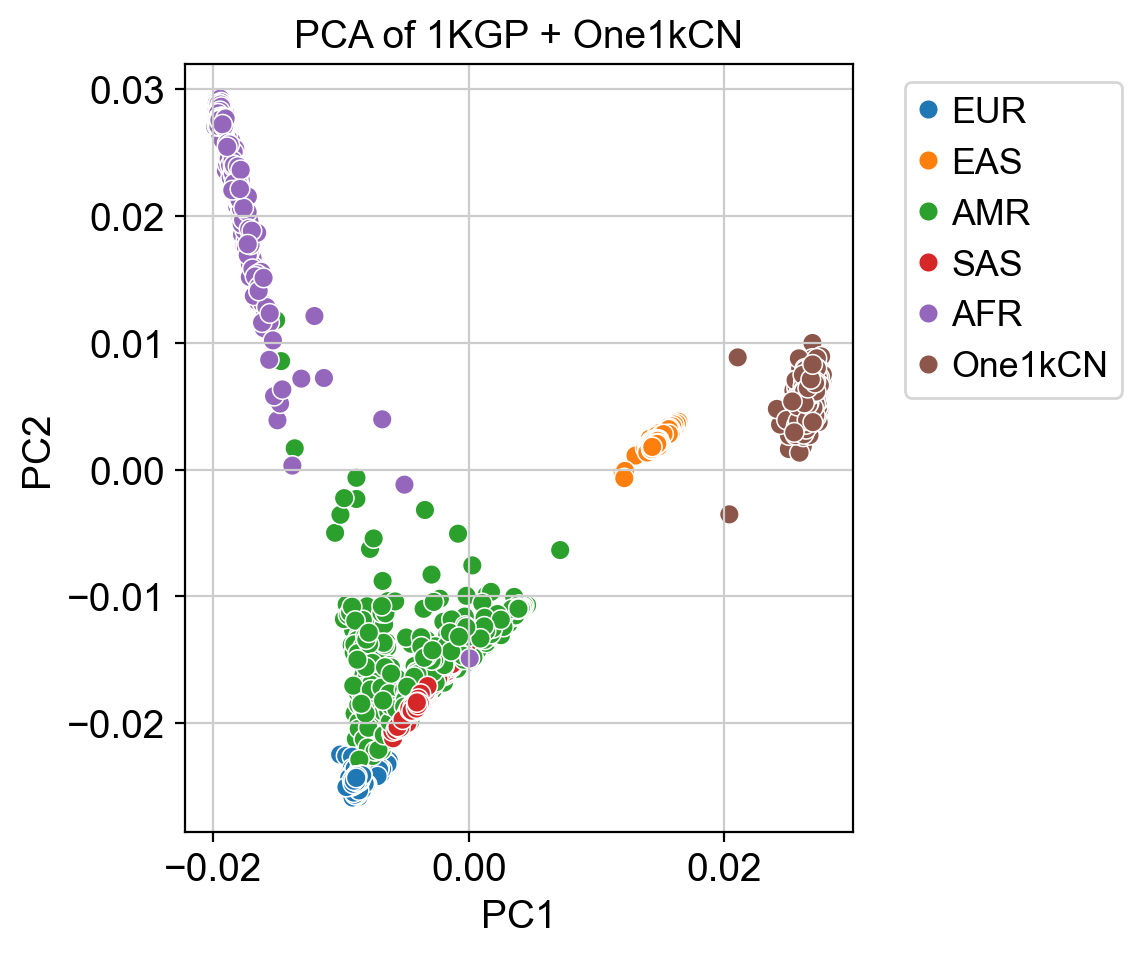

In [29]:
# 绘图
fig, ax = plt.subplots(figsize=(6, 5))  # 正确的方式
sns.scatterplot(data=pca, x="PC1", y="PC2", hue="SuperPop", s=50, palette="tab10", ax=ax)
ax.set_title("PCA of 1KGP + One1kCN")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/pca_1kgp_1kcn.pdf", dpi=300)
plt.show()

In [30]:
from umap import UMAP

In [31]:
# 选择用于 UMAP 的 PCA 维度
pc_cols = [f"PC{i}" for i in range(1, 18)]  # PC1–PC10
X_pca = pca[pc_cols].values

In [32]:
umap_model = UMAP(
    n_neighbors=30,      # 人群结构常用 10–30
    min_dist=0.5,        # 越小簇越紧
    n_components=2,
    metric="euclidean",
    random_state=42
)

umap_embedding = umap_model.fit_transform(X_pca)
pca["UMAP1"] = umap_embedding[:, 0]
pca["UMAP2"] = umap_embedding[:, 1]

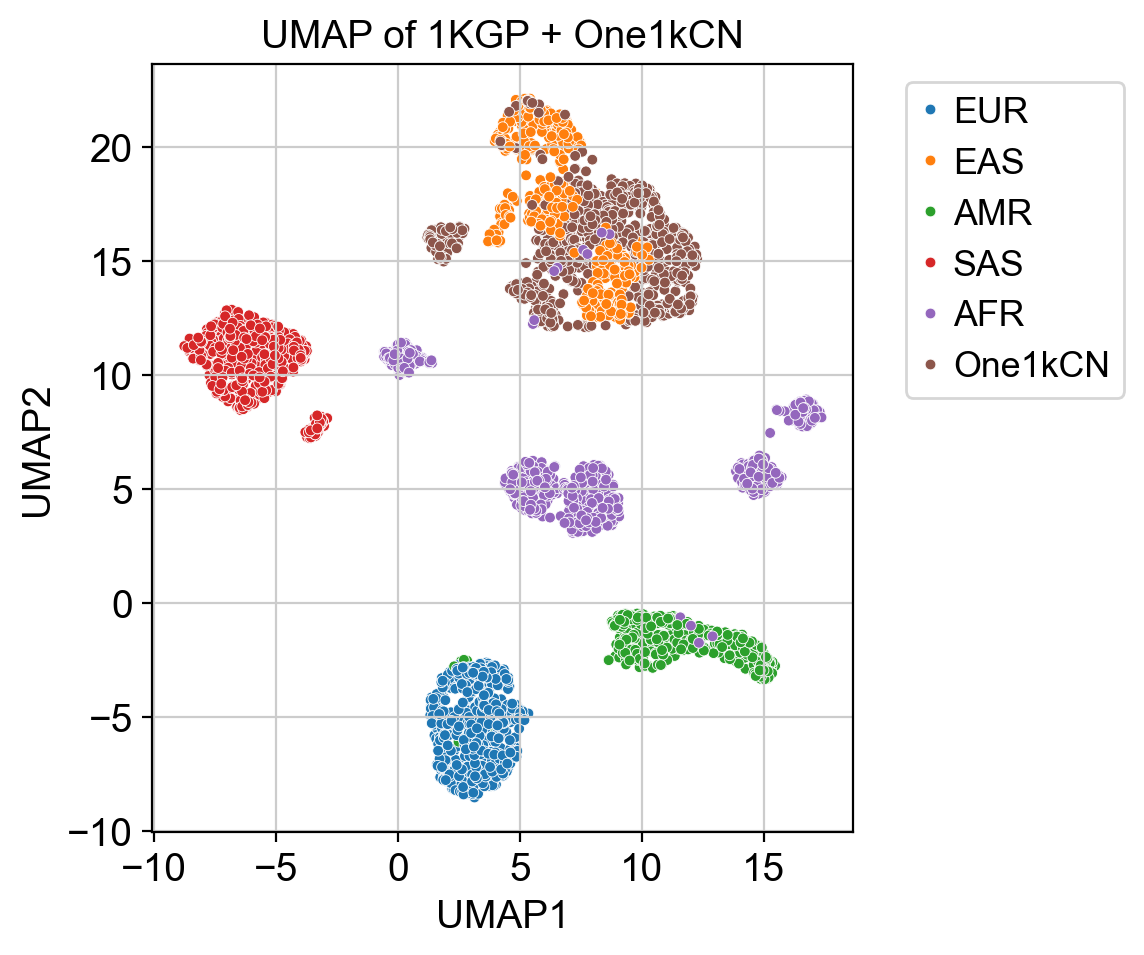

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.scatterplot(
    data=pca,
    x="UMAP1",
    y="UMAP2",
    hue="SuperPop",
    s=15,
    palette="tab10",
    ax=ax
)

ax.set_title("UMAP of 1KGP + One1kCN")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("/media/AnalysisDisk2/Yangshichen/2_My-Onek/1kGP_1kCN_PCA/umap_1kgp_1kcn.pdf",dpi=300)
plt.show()

### EAS vs 1kCN

In [ ]:
# 提取 EAS 样本
grep "EAS" 1KGP_sample_name.txt | cut -f1 > 1KGP_EAS_samples.txt

# 生成只包含 EAS 的 1KGP 数据
bcftools view -S 1KGP_EAS_samples.txt 1KGP_allchr.filtered.biallelic.snp.2504samples.vcf.gz -Oz -o 1KGP_EAS.vcf.gz

# 合并 1kCN 与 EAS 样本
plink --bfile 1kCN --bmerge 1kGP_EAS.bed 1kGP_EAS.bim 1kGP_EAS.fam --make-bed --out merged_EAS_1kCN

# 做 PCA
plink --bfile merged_EAS_1kCN --pca 20 --out merged_EAS_1kCN_pca

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 PCA 结果
pca = pd.read_csv("merged_EAS_1kCN_pca.eigenvec", delim_whitespace=True, header=None)
pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, pca.shape[1]-1)]

# 读取 EAS 样本 panel
panel = pd.read_csv("1KGP_sample_name.txt", sep="\t", usecols=[0,1,2],
                    names=["IID","Population","SuperPop"], header=0)

# 合并
pca = pca.merge(panel, on="IID", how="left")

# 区分 1kCN（因为不在 1KGP 的 panel 文件里）
pca["Group"] = pca["SuperPop"].fillna("1kCN")

# 绘制 PC1 vs PC2
plt.figure(figsize=(8,6))
for group in pca["Group"].unique():
    subset = pca[pca["Group"] == group]
    plt.scatter(subset["PC1"], subset["PC2"], label=group, alpha=0.6, s=20)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA: 1kCN vs 1KGP EAS")
plt.show()